In [1]:
import warnings
import logging
import transformers

warnings.filterwarnings("ignore")
transformers.logging.set_verbosity_error()

In [2]:
# loading dataset
from datasets import load_dataset

# data processing
import pandas as pd

# charts
import matplotlib.pyplot as plt
import seaborn as sns

# Pretreained HerBERT
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
from langchain_huggingface import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser

from pydantic import BaseModel, Field
import torch
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
dataset = load_dataset ("allegro/klej-polemo2-in", split ="test")

In [4]:
df = pd.DataFrame(dataset)

label_mapping = {
    '__label__meta_minus_m': 'Negative',
    '__label__meta_plus_m': 'Positive',
    '__label__meta_zero': 'Neutral',
}

df['text_length'] = df['sentence'].apply(len)

# remove ambigous target
df = df[df['target'] != '__label__meta_amb']

# map targets to more readable names
df['target'] = df['target'].map(label_mapping)

In [5]:
llm_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(llm_model_name)

model = AutoModelForCausalLM.from_pretrained(
    llm_model_name,
    dtype=torch.float16,
    device_map="auto"
)

hf_pipeline = pipeline(
    "text-generation",
    model = model, 
    tokenizer = tokenizer,
    device="cuda",
    return_full_text = False,
    max_new_tokens=40,      
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)   

llm = HuggingFacePipeline(pipeline = hf_pipeline)

basic_template = """ 
Sklasyfikuj nastrój tekstu, przypisując go do jednej z trzech kategorii: Positive, Negative lub Neutral.
Odpowiedz tylko i wyłącznie okreslonym formatem json.

Przykłady odpowiedzi:
{{"sentiment": "Positive", "confidence": 0.99, "reasoning": "The user expresses great enthusiasm and affection for this product."}}
{{"sentiment": "Negative", "confidence": 0.95, "reasoning": "The text contains overt criticism and disappointment with the performance and quality of the item."}}
{{"sentiment": "Neutral", "confidence": 0.91, "reasoning": "The statement is purely informative and descriptive, lacking any emotional coloring or opinion."}}

Tekst: {review}
Opdowiedź:"""

class Result(BaseModel):
    sentiment: str = Field(description="Sentiment class: positive, negative, or neutral")
    confidence: float = Field(description="Confidence score between 0.0 and 1.0")
    reasoning: str = Field(description="Short, one-sentence explanation for this choice")
    
parser = JsonOutputParser(pydantic_object=Result)

prompt = PromptTemplate.from_template(
    basic_template,
    partial_variables={"format_instructions": parser.get_format_instructions()}
)

llm_chain = prompt | llm | parser

reviews_texts = df['sentence'].tolist()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [6]:
import time

start_time = time.time()

for i in range(10):
    preds = llm_chain.invoke({"review": reviews_texts[i]})
    print(preds)

end_time = time.time()

execution_time = end_time - start_time

print(f"\nExecution time (invoke): {execution_time:.2f} seconds")

{'sentiment': 'Positive', 'confidence': 0.98, 'reasoning': "The text expresses gratitude towards the doctor's care and improvement in health over time."}
{'sentiment': 'Negative', 'confidence': 0.98, 'reasoning': "The text describes an unpleasant experience with a doctor's appointment, including frustration, disappointment, and accusations"}
{'sentiment': 'Negative', 'confidence': 0.87, 'reasoning': "The text criticizes the doctor's competence, effectiveness in treating patients, and provides examples of her"}
{'sentiment': 'Neutral', 'confidence': 0.87, 'reasoning': 'The text provides factual information about a disease prevalence rate in Poland based on data from National Foundation for'}
{'sentiment': 'Positive', 'confidence': 0.98, 'reasoning': "The text expresses satisfaction with the doctor's services, mentioning that she provides accurate diagnoses on first visits"}
{'sentiment': 'Positive', 'confidence': 0.98, 'reasoning': 'The text describes a positive experience with the doct

In [7]:
print("start")

preds = llm_chain.batch ([
    {"review": text} for text in reviews_texts
])

print("finish")

start
finish


In [12]:
preds_sentiment = [one_pred['sentiment'] for one_pred in preds]
preds_confidence  = [float(one_pred['confidence']) for one_pred in preds]

              precision    recall  f1-score   support

    Negative       0.97      0.90      0.93       300
     Neutral       0.71      0.86      0.78       117
    Positive       0.93      0.91      0.92       197

    accuracy                           0.90       614
   macro avg       0.87      0.89      0.88       614
weighted avg       0.91      0.90      0.90       614



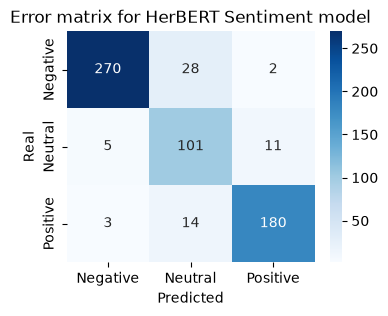


Average confidence: 0.9480293159609121


In [13]:
print(classification_report(df['target'], preds_sentiment))

plt.figure(figsize=(4, 3))
cm = confusion_matrix(df['target'], preds_sentiment, labels=['Negative', 'Neutral', 'Positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.title('Error matrix for HerBERT Sentiment model')
plt.show()

print()

print(f"Average confidence: {sum(preds_confidence) / len(preds_confidence)}")
